# Parte 1: Análisis de la base de datos

**Trabajo Práctico — Matemática III: Redes Neuronales**  
**Dataset:** Water Potability  
**Integrantes:** Micaela Ortiz y Camila Maldonado

In [3]:
# Importamos pandas para leer y manipular tablas de datos.
import pandas as pd

# Importamos numpy para trabajar con arreglos numericos y calculos matematicos.
import numpy as np

# Importamos pyplot para hacer graficos basicos.
import matplotlib.pyplot as plt

# Importamos seaborn para graficos estadisticos, como mapas de calor.
import seaborn as sns


In [4]:
# Leemos el archivo CSV ubicado en la carpeta data.
# Como el notebook esta dentro de notebooks, usamos ../ para subir una carpeta.
df = pd.read_csv("../data/water_potability.csv")

# Mostramos las primeras 5 filas para ver como viene armado el dataset.
df.head()


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [6]:
# Vemos la dimension del dataset.
# El resultado tiene la forma (cantidad_de_filas, cantidad_de_columnas).
df.shape


(3276, 10)

In [7]:
# Mostramos informacion general del DataFrame:
# - nombres de columnas
# - cantidad de valores no nulos
# - tipo de dato de cada columna
# Esto sirve para detectar faltantes y ver si las variables son numericas.
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [8]:
# Calculamos estadisticas descriptivas de las columnas numericas:
# count: cantidad de datos no nulos
# mean: promedio
# std: desvio estandar
# min/max: valores minimo y maximo
# 25%, 50%, 75%: cuartiles
df.describe()


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [ ]:
# Analizamos el balance de clases de la variable objetivo.
# Potability es la salida que queremos predecir:
# 0 = agua no potable
# 1 = agua potable
print("Distribución de la variable objetivo:")

# value_counts() cuenta cuantas muestras hay de cada clase.
print(df["Potability"].value_counts())

print("\nPorcentaje de cada clase:")

# normalize=True convierte los conteos en proporciones.
# Multiplicamos por 100 para verlo como porcentaje.
print(df["Potability"].value_counts(normalize=True) * 100)


Distribución de la variable objetivo:
Potability
0    1998
1    1278
Name: count, dtype: int64

Porcentaje de cada clase:
Potability
0    60.989011
1    39.010989
Name: proportion, dtype: float64


Potability         1.000000
Solids             0.033743
Chloramines        0.023779
Trihalomethanes    0.007130
Turbidity          0.001581
ph                -0.003556
Conductivity      -0.008128
Hardness          -0.013837
Sulfate           -0.023577
Organic_carbon    -0.030001
Name: Potability, dtype: float64


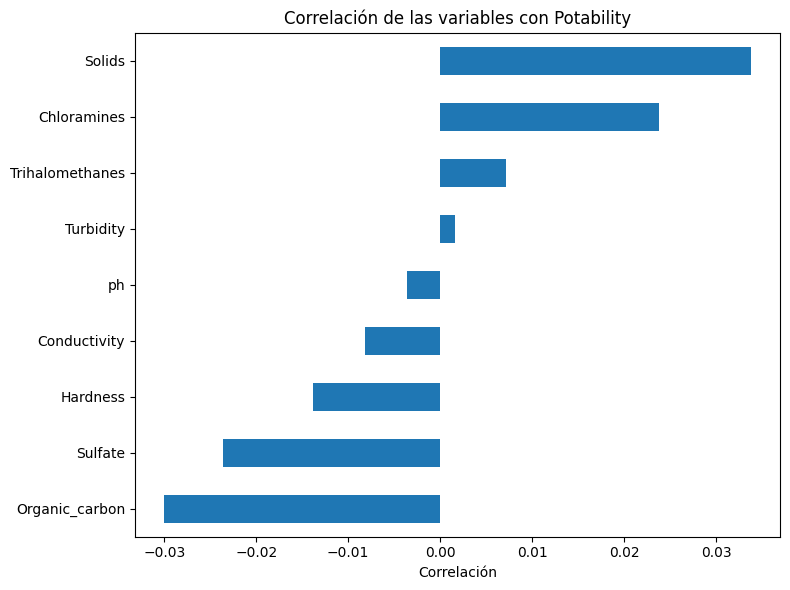

In [27]:
# Analisis de correlacion.
# La correlacion mide que tan asociada esta cada variable numerica con Potability.

# df.corr(numeric_only=True) calcula correlaciones entre columnas numericas.
# ["Potability"] selecciona la columna de correlaciones contra la variable objetivo.
# sort_values ordena de mayor a menor.
# pandas ignora automaticamente los NaN al calcular corr().
correlaciones = df.corr(numeric_only=True)["Potability"].sort_values(ascending=False)

# Imprimimos la lista de correlaciones.
print(correlaciones)

# Creamos una figura para graficar las correlaciones.
plt.figure(figsize=(8, 6))

# Quitamos Potability porque su correlacion consigo misma siempre es 1.
# Ordenamos y hacemos un grafico de barras horizontal.
correlaciones.drop("Potability").sort_values().plot(kind="barh")

# Titulo y etiqueta del eje x.
plt.title("Correlación de las variables con Potability")
plt.xlabel("Correlación")

# Ajusta los margenes para que no se corten los textos.
plt.tight_layout()

# Muestra el grafico.
plt.show()


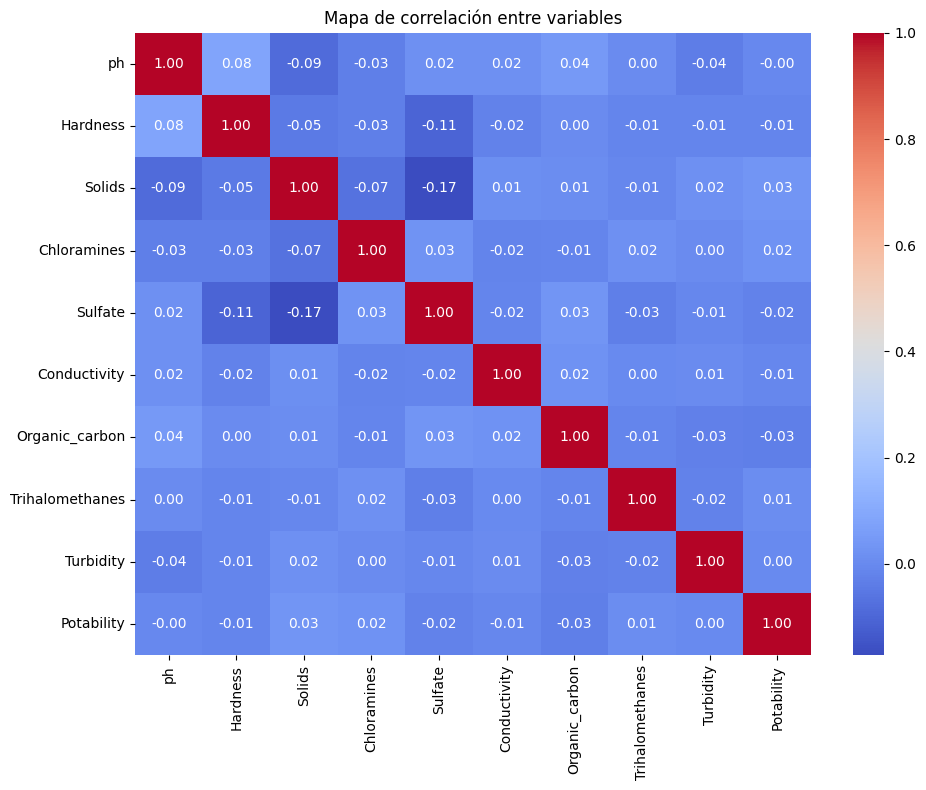

In [12]:
# Creamos una figura grande para el mapa de calor.
plt.figure(figsize=(10, 8))

# sns.heatmap dibuja una matriz de correlaciones.
# annot=True escribe los valores en cada celda.
# cmap="coolwarm" usa colores frios/calidos para correlaciones negativas/positivas.
# fmt=".2f" muestra los numeros con 2 decimales.
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")

# Agregamos titulo.
plt.title("Mapa de correlación entre variables")

# Ajustamos margenes.
plt.tight_layout()

# Mostramos el grafico.
plt.show()


In [ ]:
# Detectamos valores faltantes por columna.
# isnull() marca True donde hay NaN.
# sum() cuenta cuantos True hay en cada columna.
print("Valores faltantes:")
print(df.isnull().sum())


Valores faltantes:
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64


In [20]:
# Creamos una copia del dataset original para limpiarlo sin modificar df.
df_limpio = df.copy()

# Reemplazamos los valores faltantes de ph por la mediana de ph.
# La mediana es una medida robusta porque no se ve tan afectada por atipicos.
df_limpio["ph"] = df_limpio["ph"].fillna(df_limpio["ph"].median())

# Hacemos lo mismo con Sulfate.
df_limpio["Sulfate"] = df_limpio["Sulfate"].fillna(df_limpio["Sulfate"].median())

# Hacemos lo mismo con Trihalomethanes.
df_limpio["Trihalomethanes"] = df_limpio["Trihalomethanes"].fillna(df_limpio["Trihalomethanes"].median())

# Verificamos que ya no queden valores faltantes.
print("Valores faltantes después de imputar:")
print(df_limpio.isnull().sum())


Valores faltantes después de imputar:
ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64


In [21]:
# Detectamos datos atipicos usando el metodo IQR.
# IQR = Q3 - Q1, donde Q1 es el percentil 25 y Q3 el percentil 75.

# Lista de columnas numericas de entrada.
columnas_numericas = ["ph", "Hardness", "Solids", "Chloramines",
                      "Sulfate", "Conductivity", "Organic_carbon",
                      "Trihalomethanes", "Turbidity"]

# Recorremos cada columna numerica.
for col in columnas_numericas:
    # Primer cuartil: 25% de los datos queda por debajo.
    q1 = df_limpio[col].quantile(0.25)

    # Tercer cuartil: 75% de los datos queda por debajo.
    q3 = df_limpio[col].quantile(0.75)

    # Rango intercuartilico.
    iqr = q3 - q1

    # Limites clasicos del metodo IQR.
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    # Filtramos filas que caen fuera de esos limites.
    atipicos = df_limpio[(df_limpio[col] < limite_inferior) | (df_limpio[col] > limite_superior)]

    # Mostramos limites y cantidad de atipicos encontrados.
    print(f"{col}: lím. inferior={limite_inferior:.2f}, lím. superior={limite_superior:.2f}, atípicos={len(atipicos)}")


ph: lím. inferior=3.89, lím. superior=10.26, atípicos=142
Hardness: lím. inferior=117.13, lím. superior=276.39, atípicos=83
Solids: lím. inferior=-1832.42, lím. superior=44831.87, atípicos=47
Chloramines: lím. inferior=3.15, lím. superior=11.10, atípicos=61
Sulfate: lím. inferior=267.16, lím. superior=400.32, atípicos=264
Conductivity: lím. inferior=191.65, lím. superior=655.88, atípicos=11
Organic_carbon: lím. inferior=5.33, lím. superior=23.30, atípicos=25
Trihalomethanes: lím. inferior=26.62, lím. superior=106.70, atípicos=54
Turbidity: lím. inferior=1.85, lím. superior=6.09, atípicos=19


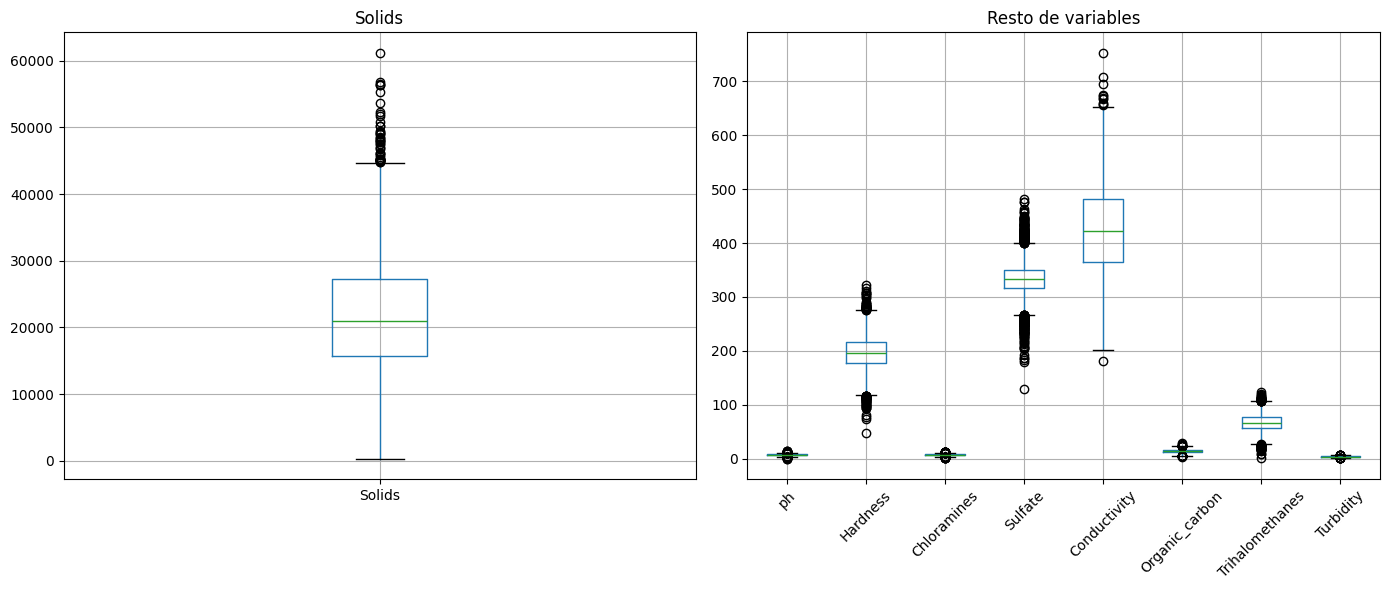

In [22]:
# Hacemos boxplots para visualizar atipicos.
# Separamos Solids porque tiene una escala mucho mayor que el resto y aplasta el grafico.

# Creamos una figura con 1 fila y 2 columnas de graficos.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot solo para Solids.
df_limpio[["Solids"]].boxplot(ax=ax1)
ax1.set_title("Solids")

# Lista de las otras variables numericas.
otras = ["ph", "Hardness", "Chloramines", "Sulfate",
         "Conductivity", "Organic_carbon", "Trihalomethanes", "Turbidity"]

# Boxplot para el resto de variables.
df_limpio[otras].boxplot(ax=ax2)
ax2.set_title("Resto de variables")

# Rotamos los nombres del eje x para que se lean mejor.
ax2.tick_params(axis='x', rotation=45)

# Ajustamos el layout y mostramos.
plt.tight_layout()
plt.show()


In [17]:
# Normalizacion de datos.
# El objetivo es que todas las variables de entrada tengan escalas comparables.

# Separamos X e y.
# X_raw contiene todas las columnas de entrada, sin Potability.
X_raw = df_limpio.drop(columns=["Potability"]).to_numpy()

# y contiene la variable objetivo.
# reshape(-1, 1) la convierte en columna, formato util para redes neuronales.
y = df_limpio["Potability"].to_numpy().reshape(-1, 1)

# Convertimos X a float para poder hacer operaciones matematicas.
X = X_raw.astype(float)

# Aplicamos Z-score columna por columna.
# Formula: z = (x - media) / desviacion
for col in range(X.shape[1]):
    # Media de la columna.
    media = X[:, col].mean()

    # Desvio estandar de la columna.
    desviacion = X[:, col].std()

    # Reemplazamos la columna por su version normalizada.
    X[:, col] = (X[:, col] - media) / desviacion

# Verificaciones.
print("Normalización completada")

# Luego de normalizar, las medias deberian quedar cerca de 0.
print("Medias (deben ser ~0):", X.mean(axis=0).round(2))

# Los desvios deberian quedar cerca de 1.
print("Desviaciones (deben ser ~1):", X.std(axis=0).round(2))

# Vemos las dimensiones finales de X e y.
print("Shape X:", X.shape)
print("Shape y:", y.shape)

# Mostramos la primera fila normalizada para ver el formato final.
print("\nPrimera fila de X normalizada:", X[0].round(4))


Normalización completada
Medias (deben ser ~0): [ 0.  0. -0.  0. -0.  0.  0. -0.  0.]
Desviaciones (deben ser ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1.]
Shape X: (3276, 9)
Shape y: (3276, 1)

Primera fila de X normalizada: [-0.0255  0.2592 -0.1395  0.1124  0.966   1.709  -1.1807  1.3054 -1.2863]
